# Notebook 5 — Incomplete parabolas

*SWC ENC 2026 · ephys-one module · independent of Notebooks 4, 6, 7*

The parabola of Notebook 3 runs from "all closed" to "all open". Real channels rarely
oblige. If the test voltage only opens a third of them, you see only the first third
of the curve; if they inactivate, the open probability never gets high. What can you
still trust? The short answer — the unitary current survives almost anything, the
channel count only when you can see the curve bend back — is the most practically
useful lesson of the whole method.

**In this notebook you will:**
1. Vary the test voltage and watch how much of the parabola you get to see.
2. Fit each partial parabola and see which estimates hold up.
3. Meet an **inactivating** channel, and see that activation and inactivation trace
   the *same* parabola.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picopatch as pp

scheme = pp.two_state()

## 1. The test voltage sets how far you get

In Notebook 1 the open probability rose with voltage along a smooth curve. Each test
voltage therefore reaches a different **maximum open probability** $p_{max}$ — and
since the mean current is $N i p$, a different distance along the parabola. Let's
mark five test voltages on the $p(V)$ curve:

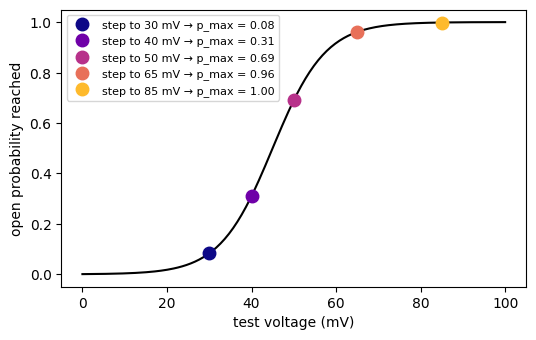

In [2]:
v_steps = [30, 40, 50, 65, 85]
V = np.linspace(0, 100, 200)
p_inf = np.array([scheme.open_probability(v) for v in V])
p_reached = [scheme.open_probability(v) for v in v_steps]

plt.figure(figsize=(6, 3.6))
plt.plot(V, p_inf, "k")
for v, p, c in zip(v_steps, p_reached, plt.cm.plasma(np.linspace(0, 0.85, 5))):
    plt.plot(v, p, "o", color=c, ms=9, label=f"step to {v} mV → p_max = {p:.2f}")
plt.xlabel("test voltage (mV)"); plt.ylabel("open probability reached"); plt.legend(fontsize=8); plt.show()

Now simulate the same patch — 100 channels, 1 pA each, 400 sweeps — stepped to each
of these voltages, and plot variance against mean. The dashed red curve is the *full*
true parabola; the dots are the part the experiment actually visits:

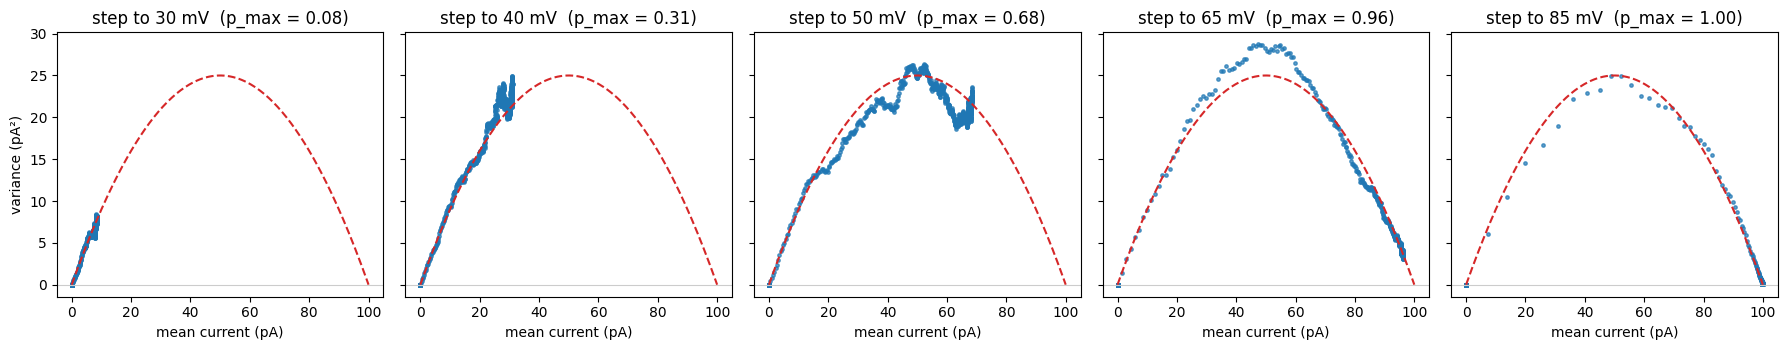

In [3]:
exps = {v: pp.make_experiment(N=100, i=1.0, scheme=scheme, protocol=pp.step_protocol(v_step=v, t_step_ms=15),
                              n_sweeps=400, seed=v) for v in v_steps}

fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharex=True, sharey=True)
for ax, v in zip(axes, v_steps):
    e = exps[v]; m, var = pp.isochrone_stats(e.sweeps)
    pp.plotting.plot_variance_mean(m, var, truth=e.truth, ax=ax, s=6, color="tab:blue",
                                   title=f"step to {v} mV  (p_max = {e.truth.p_max:.2f})")
    ax.get_legend().remove(); ax.set_ylabel("variance (pA²)" if v == v_steps[0] else "")
plt.tight_layout(); plt.show()

At 30 mV the dots cover only the first 8% of the curve and look like a straight line.
At 50 mV they reach the peak. Only at 65 and 85 mV do they come back down the far
arm. Think about what a fit can learn from each: a straight line has a slope (that's
$i$) but no curvature — and $N$ *is* the curvature.

**Exercise 1** *(~8 min)*. For each test voltage, fit the parabola and bootstrap the
uncertainty (use `pp.bootstrap_fit(sweeps, n_boot=100)` for the resampling — or your
own from Notebook 4). Plot the estimated $i$ and $N$, with their 95% intervals,
against the $p_{max}$ reached (`e.truth.p_max`).

> **Check / unstuck.** $i$ should sit near 1 pA with tight bars at every voltage;
> $N$ should be wildly uncertain (bars running off the plot, or infinite) below
> $p_{max} \approx 0.5$ and settle near 100 only at 65 and 85 mV. Stuck?
> `pp.count_channels(e)` returns the fit plus bootstrap samples (`.i_boot`, `.N_boot`).

30 mV  p_max=0.08:  i = 1.01  N = 79
40 mV  p_max=0.31:  i = 1.02  N = 109
50 mV  p_max=0.68:  i = 0.95  N = 105
65 mV  p_max=0.96:  i = 1.05  N = 95


85 mV  p_max=1.00:  i = 0.98  N = 102


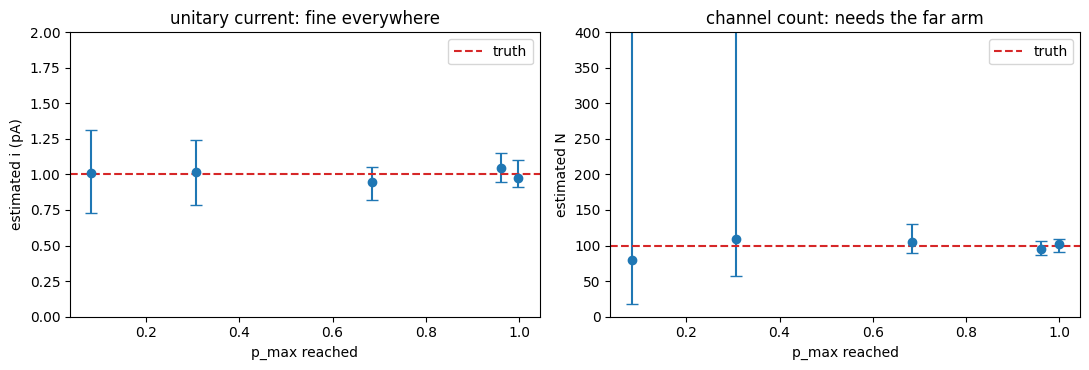

In [4]:
rows = []
for v in v_steps:
    e = exps[v]
    m, var = pp.isochrone_stats(e.sweeps)
    fit = pp.fit_parabola(m, var)
    i_b, N_b = pp.bootstrap_fit(e.sweeps, n_boot=100, rng=0)
    N_b = N_b[np.isfinite(N_b)]
    N_lo, N_hi = np.percentile(N_b, [2.5, 97.5]) if len(N_b) > 1 else (np.nan, np.nan)
    i_lo, i_hi = np.percentile(i_b, [2.5, 97.5])
    rows.append((e.truth.p_max, fit.i, i_lo, i_hi, fit.N, N_lo, N_hi))
    print(f"{v} mV  p_max={e.truth.p_max:.2f}:  i = {fit.i:.2f}  N = {fit.N:.0f}")
rows = np.array(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].errorbar(rows[:, 0], rows[:, 1], yerr=[rows[:, 1] - rows[:, 2], rows[:, 3] - rows[:, 1]], fmt="o", capsize=4)
axes[0].axhline(1.0, color="tab:red", ls="--", label="truth"); axes[0].set_ylim(0, 2)
axes[0].set_xlabel("p_max reached"); axes[0].set_ylabel("estimated i (pA)"); axes[0].set_title("unitary current: fine everywhere"); axes[0].legend()
axes[1].errorbar(rows[:, 0], rows[:, 4], yerr=[np.clip(rows[:, 4] - rows[:, 5], 0, None), np.clip(rows[:, 6] - rows[:, 4], 0, None)],
                 fmt="o", capsize=4)
axes[1].axhline(100, color="tab:red", ls="--", label="truth"); axes[1].set_ylim(0, 400)
axes[1].set_xlabel("p_max reached"); axes[1].set_ylabel("estimated N"); axes[1].set_title("channel count: needs the far arm"); axes[1].legend()
plt.tight_layout(); plt.show()

This is the paper's Fig. 9 in one plot. The practical rules:

- **The unitary current is robust.** Even a short stretch of the parabola fixes the
  initial slope. If all you can see is a straight line, report $i$ and stop.
- **The channel count needs curvature.** Until the dots clearly bend over — in
  practice $p_{max} \gtrsim 0.5$ — any $N$ you fit is a guess with enormous error
  bars. Never quote $N$ without them.
- **$p_{max}$ inherits $N$'s problems**, since $p_{max} = \langle I\rangle_{max}/(iN)$.

<details>
<summary><b>▸ Go deeper: why the curvature is so poorly determined (optional)</b></summary>

Write the parabola as $\sigma^2 = i\,m - m^2/N$. For small $m$ the second term is
smaller than the first by a factor $m/(iN) = p$. If the data only reach $p = 0.1$,
the quadratic term is at most 10% of the variance — and the variance itself is
measured with ~10% noise from a few hundred sweeps. The fit is being asked to
measure a 10% effect to 10% precision: it can't. Statistically, the two regressors
$m$ and $m^2$ are nearly collinear over a short range, so the design matrix is
ill-conditioned and $1/N$ comes with a huge standard error, while $i$ (the
well-determined direction) stays sharp.
</details>

## 2. Channels that inactivate

Many channels — sodium channels, A-type potassium channels — open on depolarisation
and then shut themselves off while the depolarisation lasts: they **inactivate**,
entering a non-conducting state from which they can't reopen until the membrane is
repolarised. The scheme gains a third state:

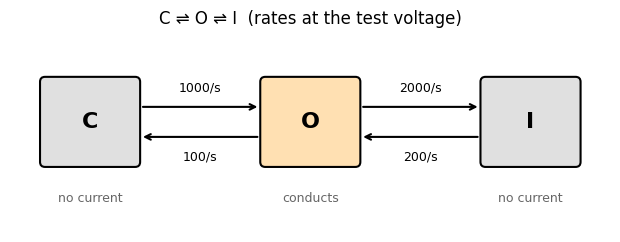

In [5]:
inact = pp.inactivating()
fig, ax = plt.subplots(figsize=(8, 2.6))
pp.plotting.plot_scheme(ax, inact, V=65, title="C ⇌ O ⇌ I  (rates at the test voltage)")
plt.show()

Here is what one such channel does on a step, and what a thousand of them do
together. Each channel opens quickly, flickers for a while, and then goes quiet for
good; the macroscopic current rises fast and then decays to a low steady level.

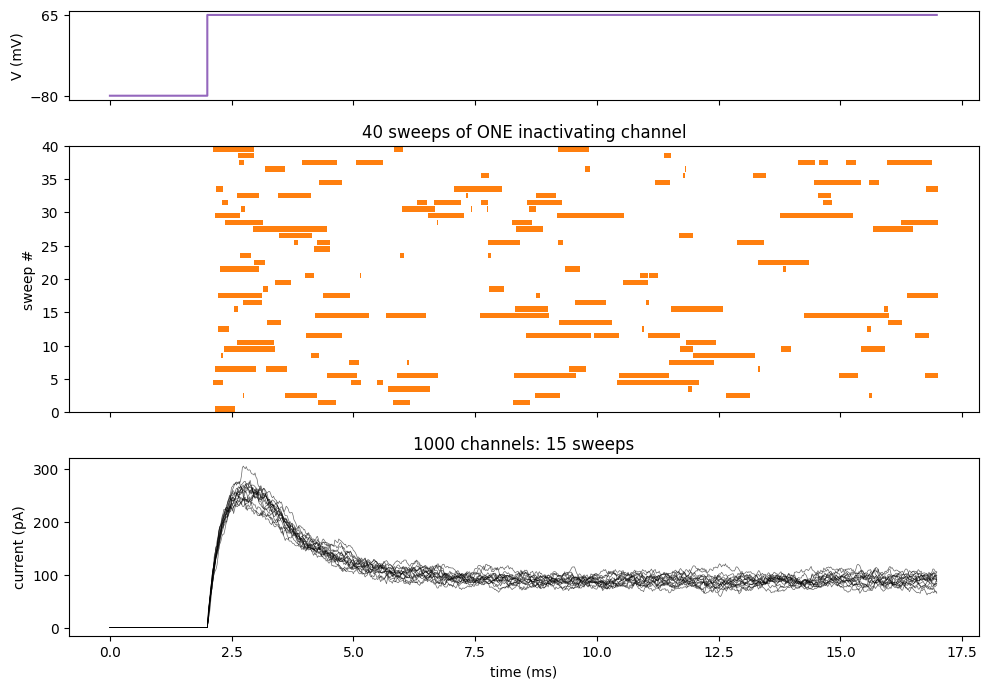

In [6]:
protocol = pp.step_protocol(v_step=65, t_step_ms=15)
states = pp.simulate_single(inact, protocol, n_sweeps=200, rng=1)
open_1 = states == 1

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, gridspec_kw=dict(height_ratios=[1, 3, 2]))
pp.plotting.plot_voltage(axes[0], protocol.t_ms, protocol.V)
pp.plotting.plot_open_raster(axes[1], open_1, protocol.t_ms, n_show=40, title="40 sweeps of ONE inactivating channel")
e_in = pp.make_experiment(N=1000, i=1.0, scheme=inact, protocol=protocol, n_sweeps=300, seed=2)
for k in range(15):
    axes[2].plot(e_in.t_ms, e_in.sweeps[k], color="k", lw=0.5, alpha=0.6)
axes[2].set_ylabel("current (pA)"); axes[2].set_xlabel("time (ms)"); axes[2].set_title("1000 channels: 15 sweeps")
plt.tight_layout(); plt.show()

Now the key observation. Time never appeared in $\sigma^2 = i\langle I\rangle -
\langle I\rangle^2/N$. The parabola doesn't care whether the current is on its way
*up* or on its way *down* — only how many channels are open. So the fast rising phase
and the slow decay should land on the **same** curve, the rising phase sparsely (few
samples, since it's quick) and the decay densely:

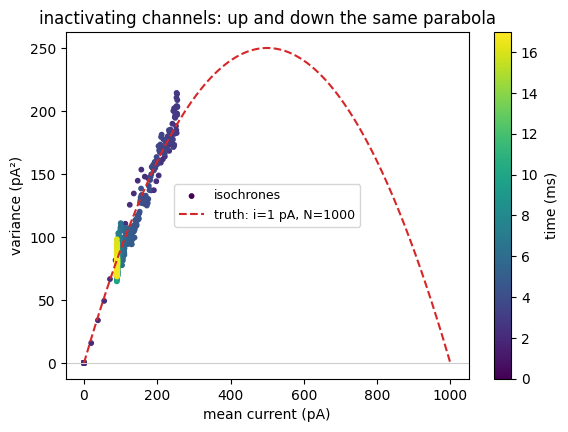

In [7]:
m, var = pp.isochrone_stats(e_in.sweeps)
pp.plotting.plot_variance_mean(m, var, truth=e_in.truth, t_ms=e_in.t_ms,
                               title="inactivating channels: up and down the same parabola")
plt.show()

**Exercise 2** *(~5 min)*. Fit the parabola to the inactivating patch and compare with
the truth (`e_in.truth`). Then look at the open probability time course,
$p(t) = \langle I\rangle / (iN)$, and read off the peak $p$.

> **Check / unstuck.** $i$ should be right; $N$ will be off — the peak open
> probability here is only ~0.25, so the dots never reach the far arm (section 1
> again, in disguise). Stuck? `pp.fit_parabola(m, var)`.

fit:   NoiseFit(i=0.969 pA, N=1204, p_max=0.22, baseline=0 pA^2)
truth: i = 1.0 pA, N = 1000, peak p = 0.25


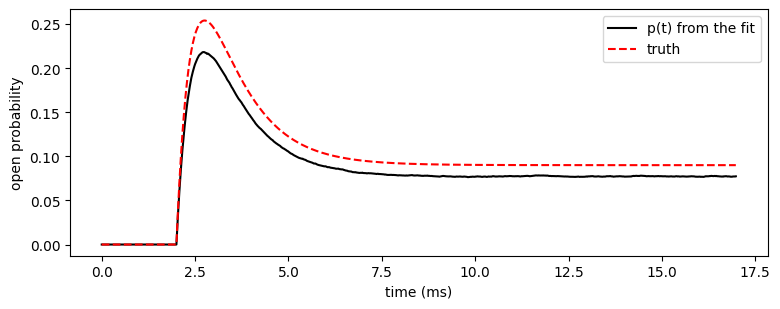

In [8]:
fit = pp.fit_parabola(m, var)
print(f"fit:   {fit}")
print(f"truth: i = {e_in.truth.i} pA, N = {e_in.truth.N}, peak p = {e_in.truth.p_max:.2f}")

plt.figure(figsize=(9, 3.2))
plt.plot(e_in.t_ms, m / (fit.i * fit.N), "k", label="p(t) from the fit")
plt.plot(e_in.t_ms, e_in.truth.p_open, "r--", label="truth")
plt.xlabel("time (ms)"); plt.ylabel("open probability"); plt.legend(); plt.show()

The paper found the same (their Fig. 10: $N$ = 842 for a true 1000). Inactivation is
not a flaw in the method — it's just a channel that never lets you see enough of the
parabola. In practice one would push $p$ higher (a stronger step, or a drug that
removes inactivation) if the channel count really mattered.

**Where we are.** A partial parabola still gives the unitary current, reliably. The
number of channels — and therefore $p_{max}$ — needs the curve to bend back, which
means an open probability well past one half. Inactivating channels are the
commonest way to be stuck on the first arm.